In [1]:
!pip install wandb
import wandb
import os
import yaml
from shutil import copytree, ignore_patterns
import xml.etree.ElementTree as ET

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

drive_repo = '/content/drive/MyDrive/Fruit-detection-yolov8-main'
# Nếu bạn để repo ở thư mục khác trên Drive, sửa lại đường dẫn này.
os.chdir(drive_repo)
print('Working directory:', os.getcwd())

In [ ]:
data_yaml = f"""
train: {drive_repo}/train/images
val: {drive_repo}/test/images

nc: 3
names: ['apple', 'banana', 'orange']
"""
with open(os.path.join(drive_repo, 'data.yaml'), 'w', encoding='utf-8') as f:
    f.write(data_yaml)
print('Updated data.yaml for Drive training:', os.path.join(drive_repo, 'data.yaml'))

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
model = YOLO('yolov8n.pt')

In [ ]:
results = model.train(
    data=f'{drive_repo}/data.yaml',
    epochs=50,
    imgsz=640,
    project=f'{drive_repo}/runs',
    name='colab_train',
    exist_ok=True
)

length of training Data 240, length of test data 60


In [ ]:
Test_image_results = model('/content/drive/MyDrive/deep/object_detect/test/images/apple_77.jpg')


image 1/1 /content/drive/MyDrive/deep/object_detect/test/images/apple_77.jpg: 512x640 5 apples, 35.6ms
Speed: 3.2ms preprocess, 35.6ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 640)


In [ ]:
Test_image_results[0].boxes.data.tolist()

[[207.3651580810547,
  147.53216552734375,
  300.0,
  229.0,
  0.8772394061088562,
  0.0],
 [113.5649185180664,
  137.05435180664062,
  214.11619567871094,
  224.51939392089844,
  0.7323520183563232,
  0.0],
 [71.38470458984375,
  62.12786865234375,
  165.02748107910156,
  152.553466796875,
  0.6354873776435852,
  0.0],
 [78.35016632080078,
  0.0,
  138.734375,
  50.681861877441406,
  0.33160021901130676,
  0.0],
 [14.11324691772461,
  23.34321403503418,
  82.14896392822266,
  88.95673370361328,
  0.2655981779098511,
  0.0]]

In [ ]:
import cv2
import matplotlib.pyplot as plt
'''Load the image'''
image = cv2.imread('/content/drive/MyDrive/deep/object_detect/test_zip/test/apple_77.jpg')
copy_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
img_dict = {0:'apple',1:'banana',2:'orange'}
'''Iterate over the bounding box predictions'''
for bbox in Test_image_results[0].boxes.data.tolist():
    x1, y1, x2, y2,confidence,label = bbox

    '''Draw rectangle'''
    cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)

    '''Add label'''
    cv2.putText(image, img_dict[int(label)], (int(x1), int(y1 - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
'''Convert BGR image to RGB'''
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

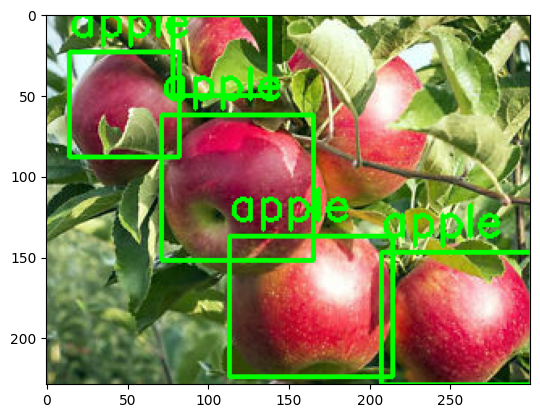

In [ ]:
plt.imshow(image_rgb)